# 01_1 - ffNN baseline profesor en RAM

Version del `01_ffnn_baseline_profesor` con la misma idea de red y lectura de etiquetas desde `xview_ann_train.json`, pero cargando las imagenes de train/valid una sola vez en memoria RAM. La diferencia clave es evitar abrir los `.tif` desde disco en cada batch de entrenamiento.


## Librerias y configuracion


In [4]:
import json
import math
import uuid
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import rasterio
from rasterio.errors import NotGeoreferencedWarning
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

2026-05-28 07:15:16.342664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779952516.534437      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779952516.588401      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779952517.028227      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779952517.028281      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779952517.028285      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# Kaggle-only: busca automaticamente xview_ann_train.json dentro de /kaggle/input.
# No dependemos del nombre exacto del Dataset en Kaggle.
KAGGLE_INPUT_DIR = Path('/kaggle/input')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError(
        'No existe /kaggle/input. Ejecuta este notebook en Kaggle y anade el dataset xview_recognition como Input.'
    )

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json dentro de /kaggle/input. '
        f'Inputs disponibles: {available_inputs}. '
        'Comprueba que has anadido el dataset xview_recognition al notebook.'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working')

print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_ROOT: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition
ANN_JSON: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


## Datos


### Lectura del JSON


In [6]:
class GenericObject:
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category = -1
        self.score = -1

class GenericImage:
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])
        self.objects = []

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)


In [7]:
def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
    with rasterio.open(DATA_ROOT / filename, 'r') as src_raster:
        img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=src_raster.profile['dtype'])
        for band in range(src_raster.count):
            img[:, :, band] = src_raster.read(band + 1)
    return img


In [8]:
with open(ANN_JSON, 'r', encoding='utf-8') as ifs:
    json_data = json.load(ifs)

categories = {
    int(k): v['name']
    for k, v in sorted(json_data['categories'].items(), key=lambda item: int(item[0]))
}
category_names = list(categories.values())
category_to_idx = {name: idx for idx, name in categories.items()}

print('Categorias:')
print(categories)
print('Imagenes en JSON:', len(json_data['images']))
print('Anotaciones en JSON:', len(json_data['annotations']))


Categorias:
{0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}
Imagenes en JSON: 18746
Anotaciones en JSON: 18746


In [9]:
counts = dict.fromkeys(category_names, 0)
anns = []

for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])

    obj = GenericObject()
    obj.bb = tuple(int(x) for x in json_ann['bbox'])
    obj.category = json_ann['category_id']

    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)

print('Numero de imagenes train:', len(anns))
print('Distribucion por clase:')
for name, count in counts.items():
    print(f'{name:20s}: {count}')


Numero de imagenes train: 18746
Distribucion por clase:
Cargo plane         : 635
Small car           : 3324
Bus                 : 1768
Truck               : 2210
Motorboat           : 1069
Fishing vessel      : 706
Dump truck          : 1236
Excavator           : 789
Building            : 3594
Helipad             : 111
Storage tank        : 1469
Shipping container  : 1523
Pylon               : 312


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Indice de clase: 8
Bounding box: (0, 0, 224, 224)
Primeros pixeles del array:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]


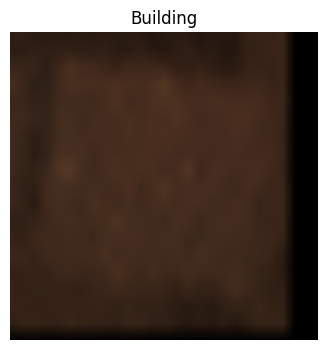

In [10]:
sample_ann = anns[0]
sample_obj = sample_ann.objects[0]
sample_img = load_geoimage(sample_ann.filename)

print('Filename:', sample_ann.filename)
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', sample_obj.category)
print('Indice de clase:', category_to_idx[sample_obj.category])
print('Bounding box:', sample_obj.bb)
print('Primeros pixeles del array:')
print(sample_img[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(sample_obj.category)
plt.axis('off')
plt.show()


### Split train/valid


In [11]:
anns_train, anns_valid = train_test_split(
    anns,
    test_size=0.1,
    random_state=1,
    shuffle=True,
)

print('Number of training images:', len(anns_train))
print('Number of validation images:', len(anns_valid))


Number of training images: 16871
Number of validation images: 1875


### Carga en memoria RAM

En este notebook cargamos las imagenes una sola vez antes de entrenar. Esto usa mas RAM, pero evita que la GPU espere a que `rasterio` abra archivos `.tif` en cada batch.


In [12]:
def annotations_to_arrays(annotations):
    images, labels_idx = [], []
    for ann in annotations:
        image = load_geoimage(ann.filename)
        images.append(image)
        labels_idx.append(category_to_idx[ann.objects[0].category])

    X = np.stack(images).astype(np.uint8)
    y_idx = np.array(labels_idx, dtype=np.int32)
    y = tf.keras.utils.to_categorical(y_idx, num_classes=len(categories)).astype(np.float32)
    return X, y, y_idx

X_train, y_train, y_train_idx = annotations_to_arrays(anns_train)
X_valid, y_valid, y_valid_idx = annotations_to_arrays(anns_valid)

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)


X_train: (16871, 224, 224, 3) uint8 RAM aprox: 2.365147590637207 GB
X_valid: (1875, 224, 224, 3) uint8 RAM aprox: 0.26285648345947266 GB
y_train: (16871, 13) float32
y_valid: (1875, 13) float32


## Red


### Arquitectura y summary


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Activation('relu'),
    Dense(len(categories)),
    Activation('softmax'),
])

opt = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1779953473.413909      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779953473.419884      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │     1,956,877 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,956,877 (7.46 MB)

 Trainable params: 1,956,877 (7.46 MB)

 Non-trainable params: 0 (0.00 B)

### Callbacks


In [14]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

MODEL_PATH = WORKDIR / '01_1_ffnn_baseline_profesor_ram.keras'
callbacks = [
    ModelCheckpoint(str(MODEL_PATH), monitor='val_accuracy', verbose=1, save_best_only=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=40, verbose=1),
    TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/01_1_ffnn_baseline_profesor_ram.keras


### Entrenamiento


In [15]:
epochs = 20
batch_size = 16

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1,
)

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)


Epoch 1/20


I0000 00:00:1779953480.977812     138 service.cc:152] XLA service 0x7cb648026c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779953480.977846     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779953480.977850     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779953481.183379     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  53/1055 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1433 - loss: 7649.8174

I0000 00:00:1779953482.415615     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2332 - loss: 4093.6630
Epoch 1: val_accuracy improved from None to 0.29227, saving model to /kaggle/working/01_1_ffnn_baseline_profesor_ram.keras

Epoch 1: finished saving model to /kaggle/working/01_1_ffnn_baseline_profesor_ram.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2578 - loss: 3717.4185 - val_accuracy: 0.2923 - val_loss: 4892.2041 - learning_rate: 0.0010
Epoch 2/20
1052/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3009 - loss: 3778.6061
Epoch 2: val_accuracy did not improve from 0.29227
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2983 - loss: 3702.8452 - val_accuracy: 0.2795 - val_loss: 4850.4805 - learning_rate: 0.0010
Epoch 3/20
1051/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3108 - loss: 3584.0930
Epoch 3: val_accuracy improved from 0.29227 to 0.35040, saving model to /kaggle/working/01_1_ffnn_baseline_profesor_ram.keras

Epoch 3: finished saving model to /kaggle/working/

## Resultados


### Graficas de entrenamiento


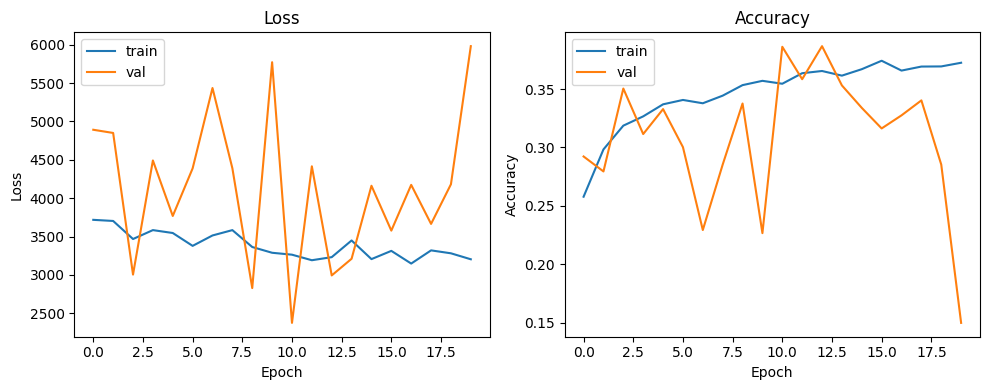

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Matriz de confusion


In [17]:
model.load_weights(MODEL_PATH)
probs = model.predict(X_valid, batch_size=64, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx

cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(categories))))


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


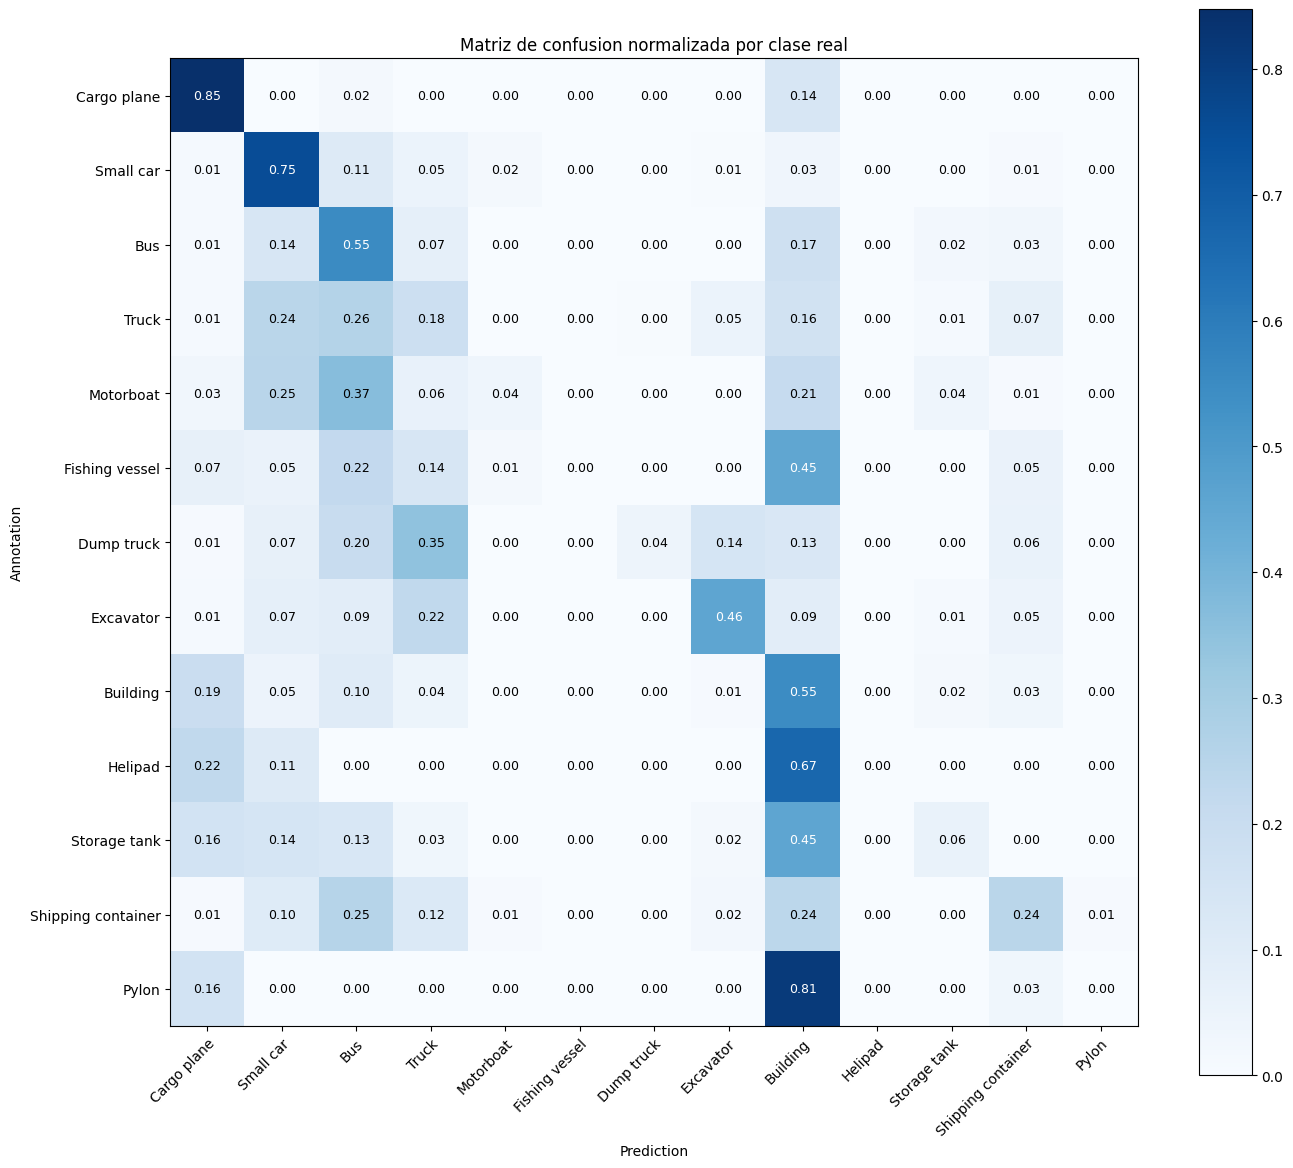

In [18]:
def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    ax.set_title('Matriz de confusion normalizada por clase real')
    fig.tight_layout()
    plt.show()

draw_confusion_matrix_percent(cm, category_names)


### Metricas por clase


In [19]:
correct = np.diag(cm).astype(float)
total_true = np.sum(cm, axis=1).astype(float)
total_pred = np.sum(cm, axis=0).astype(float)

print('Mean Accuracy: %.3f%%' % (np.sum(correct) / np.sum(total_true) * 100))
print('Mean Recall: %.3f%%' % ((correct / np.maximum(total_true, np.finfo(np.float64).eps)).mean() * 100))
print('Mean Precision: %.3f%%' % ((correct / np.maximum(total_pred, np.finfo(np.float64).eps)).mean() * 100))

for idx, name in enumerate(category_names):
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    recall = tp / np.maximum(tp + fn, np.finfo(np.float64).eps)
    precision = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)
    specificity = tn / np.maximum(tn + fp, np.finfo(np.float64).eps)
    f1_score = 2 * ((precision * recall) / np.maximum(precision + recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (name, recall * 100, precision * 100, specificity * 100, f1_score * 100))


Mean Accuracy: 38.667%
Mean Recall: 28.641%
Mean Precision: 30.521%
> Cargo plane: Recall: 84.746% Precision: 29.240% Specificity: 93.337% Dice: 43.478%
> Small car: Recall: 75.380% Precision: 57.674% Specificity: 88.228% Dice: 65.349%
> Bus: Recall: 55.172% Precision: 25.600% Specificity: 83.598% Dice: 34.973%
> Truck: Recall: 18.257% Precision: 23.529% Specificity: 91.248% Dice: 20.561%
> Motorboat: Recall: 3.670% Precision: 30.769% Specificity: 99.490% Dice: 6.557%
> Fishing vessel: Recall: 0.000% Precision: 0.000% Specificity: 99.945% Dice: 0.000%
> Dump truck: Recall: 4.237% Precision: 71.429% Specificity: 99.886% Dice: 8.000%
> Excavator: Recall: 45.679% Precision: 48.052% Specificity: 97.770% Dice: 46.835%
> Building: Recall: 54.821% Precision: 39.960% Specificity: 80.225% Dice: 46.225%
> Helipad: Recall: 0.000% Precision: 0.000% Specificity: 100.000% Dice: 0.000%
> Storage tank: Recall: 5.921% Precision: 32.143% Specificity: 98.897% Dice: 10.000%
> Shipping container: Recall: 2

## Codabench

El conjunto test no tiene etiquetas publicas. Esta seccion recorre `xview_test`, genera `prediction.json` y lo comprime como `submission.zip`.


In [20]:
anns_test = []
for path in sorted(TEST_DIR.glob('*.tif')):
    image = GenericImage(f'xview_test/{path.name}')
    image.tile = np.array([0, 0, 224, 224])
    obj = GenericObject()
    obj.bb = (0, 0, 224, 224)
    image.add_object(obj)
    anns_test.append(image)

print('Number of testing images:', len(anns_test))


Number of testing images: 2365


In [21]:
model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(anns_test), batch_size):
    batch_anns = anns_test[start:start + batch_size]
    images = np.stack([load_geoimage(ann.filename) for ann in batch_anns]).astype(np.uint8)
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    pred_idx = np.argmax(probs, axis=1)

    for offset, (ann, cls_idx) in enumerate(zip(batch_anns, pred_idx)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': ann.filename.split('/')[-1],
            'filename': ann.filename,
            'width': int(ann.tile[2]),
            'height': int(ann.tile[3]),
        }
        predictions_data['annotations'][idx] = {
            'image_id': ann.filename.split('/')[-1],
            'category_id': category_names[int(cls_idx)],
            'bbox': [int(x) for x in ann.objects[0].bb],
        }

    print(f'Procesadas {min(start + batch_size, len(anns_test))}/{len(anns_test)}')

prediction_path = WORKDIR / 'prediction_01.json'
submission_path = WORKDIR / 'submission_01.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_01.json - 661016 bytes
/kaggle/working/submission_01.zip - 136104 bytes


/kaggle/working/submission_01.zip